## Hotel Booking Data Analysis and Clustering Using PCA and Machine Learning



all required libraries and tools are imported to support data analysis, preprocessing, statistical testing, dimensionality reduction, and machine learning tasks.



In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  
import numpy as np
import warnings 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import norm
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA


Dataset Loading

In [115]:


df = pd.read_csv("hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Data Wrangling
## 1-Handling Missing Values

Missing values were handled to ensure data consistency and model reliability.

 - The "country" feature was imputed using the mode, as it represents a categorical variable.
 - The "agent" and "company" features were filled with zero, indicating the absence of an assigned agent or company.
 - The "children" feature was filled with zero, assuming no children were included when the value was missing.

After imputation, a final check was performed to confirm that no missing values remained in the dataset.


In [116]:
df['country'] = df['country'].fillna(df['country'].mode()[0])




In [117]:
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)


In [118]:
df['children'] = df['children'].fillna(0)


In [119]:
df.isnull().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

## 2-Removing Duplicates and Outlier Detection

Duplicate records were identified and removed to prevent biased analysis and ensure data integrity.

The dataset shape was examined before and after removing duplicates to confirm the reduction in redundant observations.

Following duplicate removal, a boxplot was used to visually inspect the distribution of the Average Daily Rate (ADR) and detect potential outliers that could negatively impact statistical analysis and modeling.


In [120]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)


Before removing duplicates: (119390, 32)
After removing duplicates: (87377, 32)


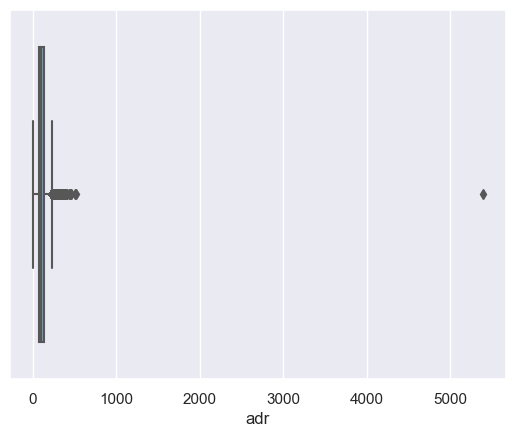

In [121]:
sns.boxplot(x=df['adr'])
plt.show()


## 3-Outlier Removal Using the IQR Method

Outliers in the **Average Daily Rate (ADR)** feature were identified and removed using the Interquartile Range (IQR) method.

- The first quartile (Q1) and third quartile (Q3) were computed to measure data dispersion.
- The IQR was calculated as the difference between Q3 and Q1.

Observations falling outside the range:
- **Q1 − 1.5 × IQR**
- **Q3 + 1.5 × IQR**

were considered outliers and removed from the dataset.

This step helps reduce the impact of extreme values and improves the reliability of statistical analysis and machine learning models.


In [122]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['adr'] >= lower) & (df['adr'] <= upper)]


## 4-ADR Distribution After Outlier Removal

After removing outliers using the IQR method, the boxplot of the "Average Daily Rate (ADR)" shows a more compact and stable distribution.

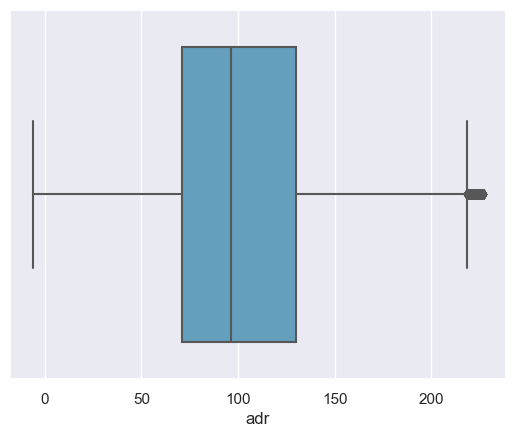

In [123]:
sns.boxplot(x=df['adr'])
plt.show()


In [124]:
df.shape


(84889, 32)

In [125]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 84889 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84889 non-null  object 
 1   is_canceled                     84889 non-null  int64  
 2   lead_time                       84889 non-null  int64  
 3   arrival_date_year               84889 non-null  int64  
 4   arrival_date_month              84889 non-null  object 
 5   arrival_date_week_number        84889 non-null  int64  
 6   arrival_date_day_of_month       84889 non-null  int64  
 7   stays_in_weekend_nights         84889 non-null  int64  
 8   stays_in_week_nights            84889 non-null  int64  
 9   adults                          84889 non-null  int64  
 10  children                        84889 non-null  float64
 11  babies                          84889 non-null  int64  
 12  meal                            8488

## 5-Date Conversion and Data Type Correction

The **reservation_status_date** feature was converted to a datetime format to ensure proper handling of date-based operations.




In [126]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])


## Final Dataset Validation

After completing all preprocessing steps, a final validation was performed to confirm the structure and integrity of the cleaned dataset.

- The dataset shape was inspected to verify the number of remaining records and features after removing duplicates and outliers.
- The dataset information was reviewed to ensure:
- Correct data types for all features
- Absence of missing values
- Consistency across numerical and categorical variables

This final check confirms that the dataset is clean, well-structured, and ready for further analysis and machine learning modeling.


In [127]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 84889 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           84889 non-null  object        
 1   is_canceled                     84889 non-null  int64         
 2   lead_time                       84889 non-null  int64         
 3   arrival_date_year               84889 non-null  int64         
 4   arrival_date_month              84889 non-null  object        
 5   arrival_date_week_number        84889 non-null  int64         
 6   arrival_date_day_of_month       84889 non-null  int64         
 7   stays_in_weekend_nights         84889 non-null  int64         
 8   stays_in_week_nights            84889 non-null  int64         
 9   adults                          84889 non-null  int64         
 10  children                        84889 non-null  float64       
 11  babies

## Exploratory Data Analysis (EDA)
## Dataset Columns and Data Types

This step presents a structured overview of the dataset columns along with their corresponding data types.

The purpose of this step is to:
 - Identify numerical and categorical features
 - Verify correct data type assignments
 - Support decisions for encoding and preprocessing
- Improve understanding of the dataset structure

This information is essential for effective feature engineering and model preparation.


In [128]:
columns_info = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

columns_info


,Column Name,Data Type
0,hotel,object
1,is_canceled,int64
2,lead_time,int64
3,arrival_date_year,int64
4,arrival_date_month,object
5,arrival_date_week_number,int64
6,arrival_date_day_of_month,int64
7,stays_in_weekend_nights,int64
8,stays_in_week_nights,int64
9,adults,int64


## Environment Setup and Data Loading

In [129]:


sns.set_theme(style="darkgrid")
sns.set_palette("icefire")


warnings.filterwarnings("ignore")

df = pd.read_csv("hotel_bookings.csv", parse_dates=["reservation_status_date"])
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Average Daily Rate (ADR) Trend Over Time

This analysis examines how the Average Daily Rate (ADR) changes across different arrival years.

Steps performed:
- Group the dataset by arrival year
- Compute the mean ADR for each year
- Visualize the yearly trend using a line plot

This visualization helps identify pricing trends over time and provides insight into how hotel pricing strategies have evolved across different years.


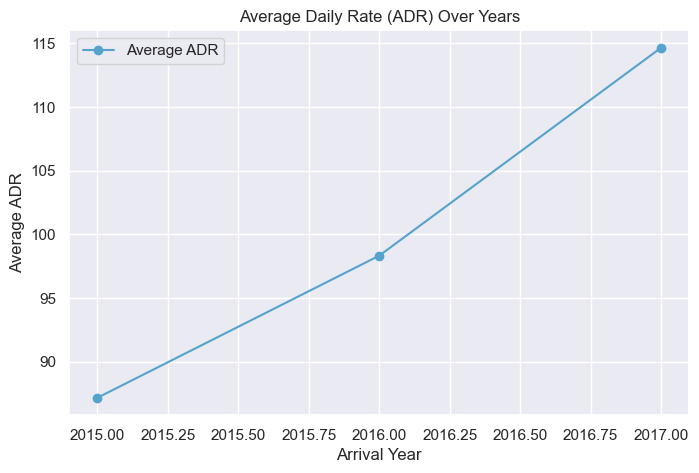

In [130]:

adr_by_year = df.groupby("arrival_date_year")["adr"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(adr_by_year["arrival_date_year"],
         adr_by_year["adr"],
         marker='o',
         label="Average ADR")

plt.title("Average Daily Rate (ADR) Over Years")
plt.xlabel("Arrival Year")
plt.ylabel("Average ADR")
plt.legend()
plt.show()


## Booking and Cancellation Analysis by Hotel Type

This section analyzes booking behavior across different hotel types by examining:

- The total number of bookings per hotel type
- The total number of canceled bookings per hotel type

- Two bar charts are used for comparison:
- The first chart shows the overall booking volume for each hotel type.
- The second chart shows the number of cancellations for each hotel type.

This analysis helps identify differences in demand and cancellation behavior between hotel categories, providing insight into customer behavior and potential operational challenges.


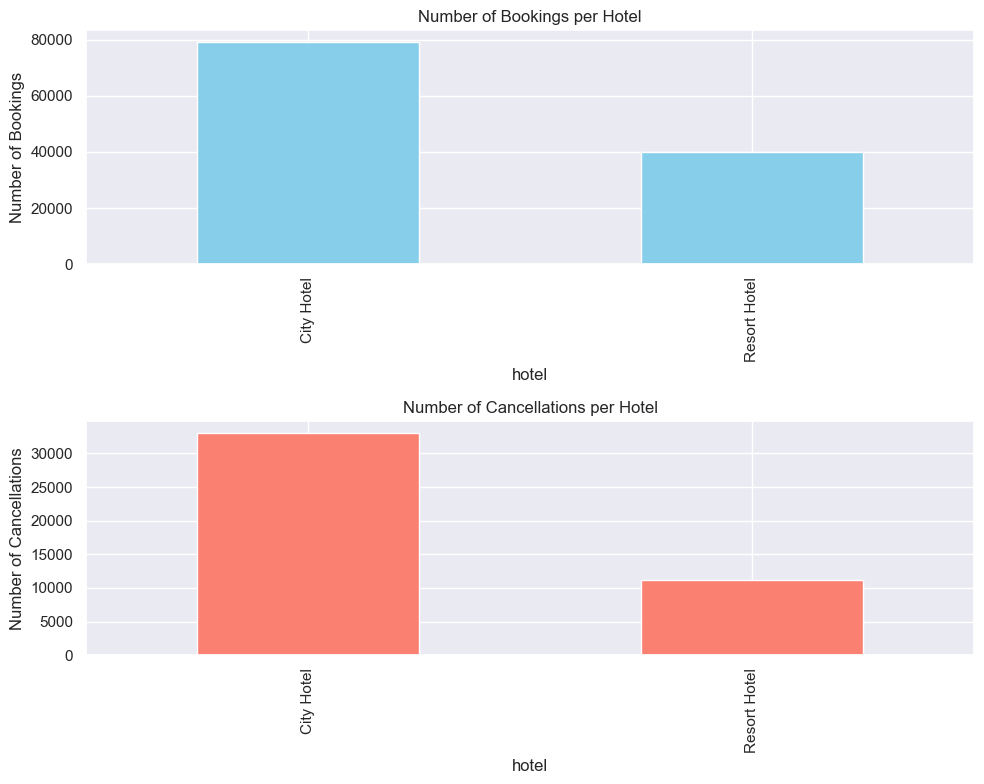

In [131]:
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
hotel_counts = df['hotel'].value_counts()
hotel_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Bookings per Hotel")
plt.ylabel("Number of Bookings")

plt.subplot(2,1,2)
canceled_counts = df.groupby('hotel')['is_canceled'].sum()
canceled_counts.plot(kind='bar', color='salmon')
plt.title("Number of Cancellations per Hotel")
plt.ylabel("Number of Cancellations")

plt.tight_layout()
plt.show()


## Monthly Booking Trends

This visualization shows the distribution of hotel bookings across different months of the year.

Key points of this analysis:
 - The data is grouped by arrival month to calculate the total number of bookings per month.
 - Months are ordered chronologically to clearly reflect seasonal trends.
 - A line plot is used to highlight increases and decreases in booking activity over time.

This analysis helps identify:
- Peak booking seasons
- Low-demand months
- Seasonal patterns in customer booking behavior

Understanding these trends is essential for capacity planning, pricing strategies, and demand forecasting in the hotel industry.


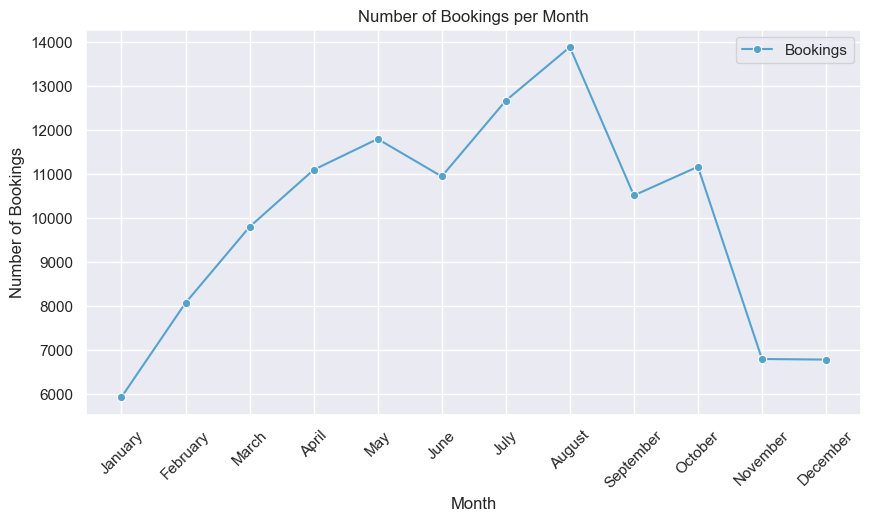

In [132]:

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]


bookings_per_month = df.groupby("arrival_date_month")["is_canceled"].count().reindex(month_order)

plt.figure(figsize=(10,5))
sns.lineplot(x=bookings_per_month.index,
             y=bookings_per_month.values,
             marker="o",
             label="Bookings")

plt.title("Number of Bookings per Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.legend()
plt.show()


## Lead Time Distribution Analysis

This histogram illustrates the distribution of booking lead time, which represents the number of days between the booking date and the arrival date.

Key observations:
- Most bookings are made with a short lead time, indicating that customers often book close to their arrival date.
- The distribution is right-skewed, with a long tail representing bookings made far in advance.
- A small number of bookings have very high lead times, which may be considered extreme or rare cases.

 important because :
- Lead time is a critical factor in understanding customer booking behavior.
- It helps hotels improve demand forecasting and revenue management strategies.
- Extreme lead times can influence cancellation likelihood and pricing decisions.


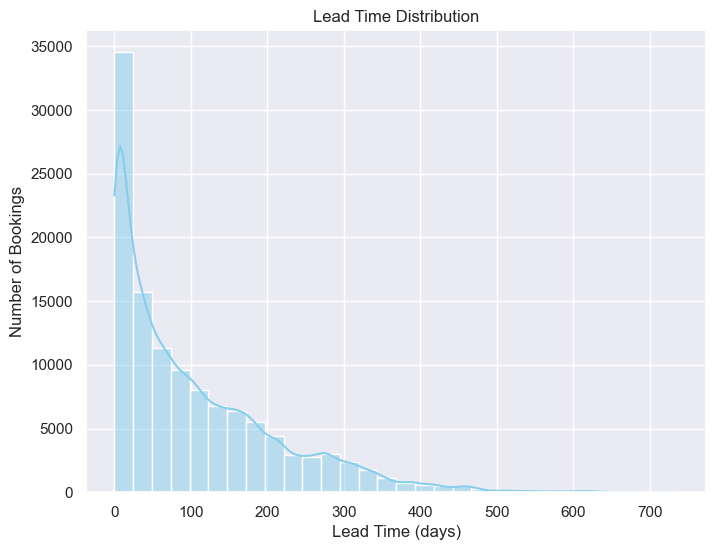

In [133]:
plt.figure(figsize=(8,6))
sns.histplot(df['lead_time'], bins=30, kde=True, color='skyblue')
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Bookings")
plt.show()


## Hotel Type Distribution

This visualization shows the distribution of bookings across different hotel types in the dataset.

Key observations:
- City Hotels have a significantly higher number of bookings compared to Resort Hotels.
- This indicates that urban destinations attract more frequent bookings, possibly due to business travel or shorter stays.
- Resort Hotels receive fewer bookings, which may be associated with seasonal or leisure-based travel.

Why this analysis is important:
- Understanding hotel type distribution helps identify demand patterns.
- It provides context for later analyses such as cancellation rates, pricing behavior, and customer segmentation.
- Hotel type can be a strong factor influencing booking behavior and cancellation probability.


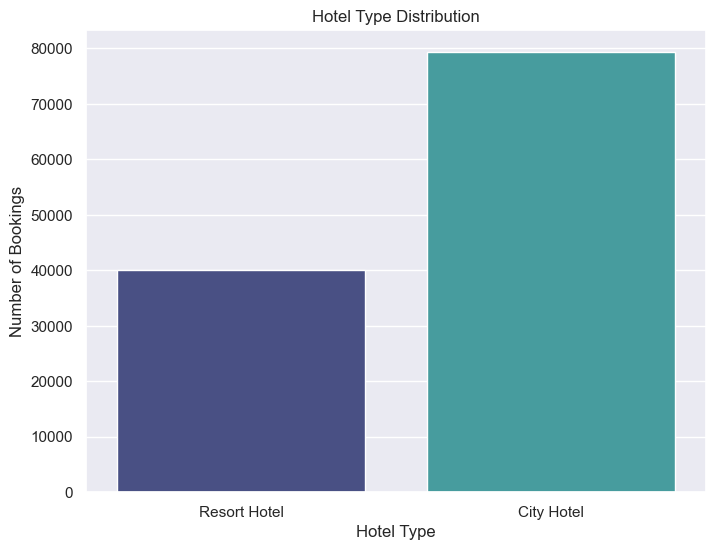

In [134]:
plt.figure(figsize=(8,6))
sns.countplot(x='hotel', data=df, palette='mako')
plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()


## Lead Time vs Average Daily Rate (ADR)

This scatter plot illustrates the relationship between the lead time (number of days between booking and arrival)
and the Average Daily Rate (ADR).

Key observations:
- Most bookings are concentrated at lower ADR values, regardless of lead time.
- There is no strong linear relationship between lead time and ADR.
- A few extreme outliers appear with very high ADR values, which may represent special cases such as luxury bookings or data anomalies.
- Bookings with long lead times tend to have more stable and moderate ADR values.

Why this analysis is important:
- Understanding the relationship between lead time and price helps in pricing strategy design.
- It provides insights into customer booking behavior and demand planning.
- This analysis supports later steps such as feature selection and dimensionality reduction.


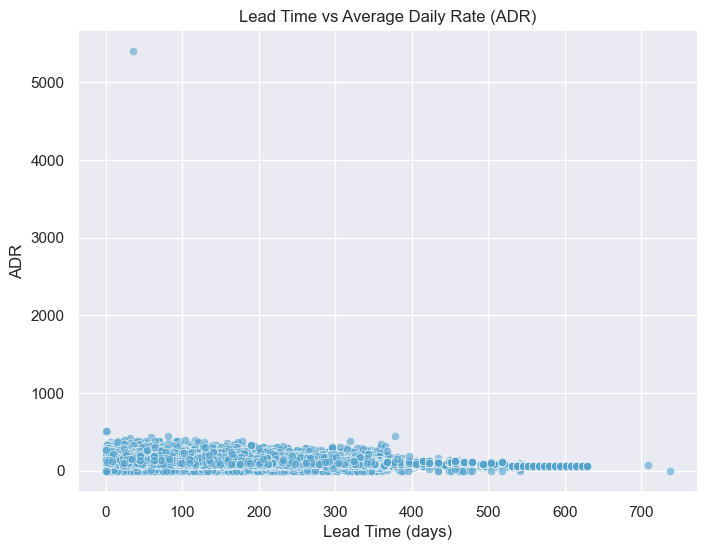

In [135]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='lead_time', y='adr', data=df, alpha=0.6)
plt.title("Lead Time vs Average Daily Rate (ADR)")
plt.xlabel("Lead Time (days)")
plt.ylabel("ADR")
plt.show()


## Average ADR by Hotel Type and Cancellation Status

This bar chart compares the Average Daily Rate (ADR) across different hotel types
(City Hotel and Resort Hotel), while also distinguishing between canceled and non-canceled bookings.

Key observations:
- For both hotel types, canceled bookings generally show a higher average ADR than non-canceled bookings.
- City Hotels tend to have a higher ADR overall compared to Resort Hotels.
- The difference in ADR between canceled and non-canceled bookings is more noticeable in Resort Hotels.

Interpretation:
- Higher ADR bookings are more likely to be canceled, which may indicate price sensitivity among customers.
- City Hotels may attract higher-paying customers due to location and business demand.
- This insight can help hotel management adjust pricing and cancellation policies.

Why this analysis is important:
- It highlights the relationship between pricing and cancellation behavior.
- It supports decision-making for revenue management and risk reduction.
- These patterns justify the use of pricing-related features in later modeling steps.


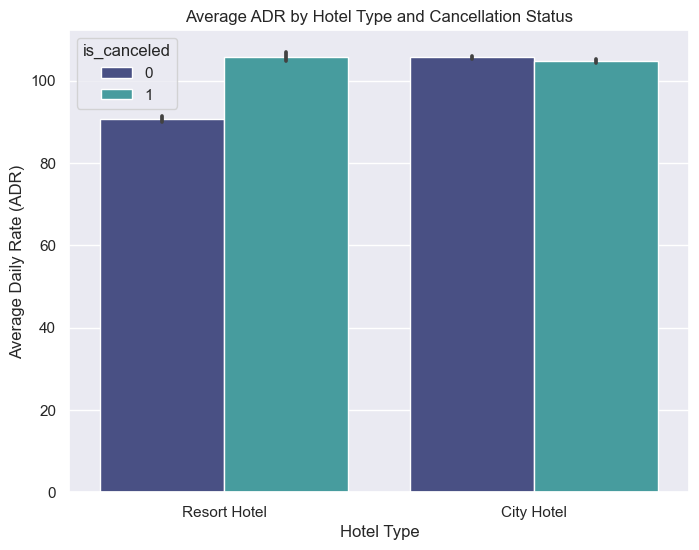

In [136]:
plt.figure(figsize=(8,6))
sns.barplot(x='hotel', y='adr', hue='is_canceled', data=df, palette='mako')
plt.title("Average ADR by Hotel Type and Cancellation Status")
plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate (ADR)")
plt.show()


## Correlation Heatmap Analysis

This heatmap illustrates the pairwise Pearson correlation between numerical features
in the hotel booking dataset. It helps identify relationships, dependencies, and potential
redundancies among variables.

Key observations:
- `is_canceled` shows a moderate positive correlation with `lead_time`, indicating that
  bookings made far in advance are more likely to be canceled.
- `stays_in_weekend_nights` and `stays_in_week_nights` have a strong positive correlation,
  which is expected since longer stays usually include both weekdays and weekends.
- `arrival_date_year` and `arrival_date_week_number` show a noticeable negative correlation,
  reflecting seasonal and calendar-based patterns.
- Most features exhibit weak correlations, suggesting low multicollinearity across the dataset.

Interpretation:
- Features with higher correlation to `is_canceled` are important candidates for predictive
  modeling and feature selection.
- Strong correlations between duration-related features indicate redundancy, which justifies
  dimensionality reduction techniques such as PCA.
- The overall low correlation structure supports the use of clustering and unsupervised learning.

Why this step is important:
- It provides insight into feature relationships before modeling.
- It helps detect redundant variables and guides feature selection.
- It supports later steps such as PCA and clustering by understanding data structure.


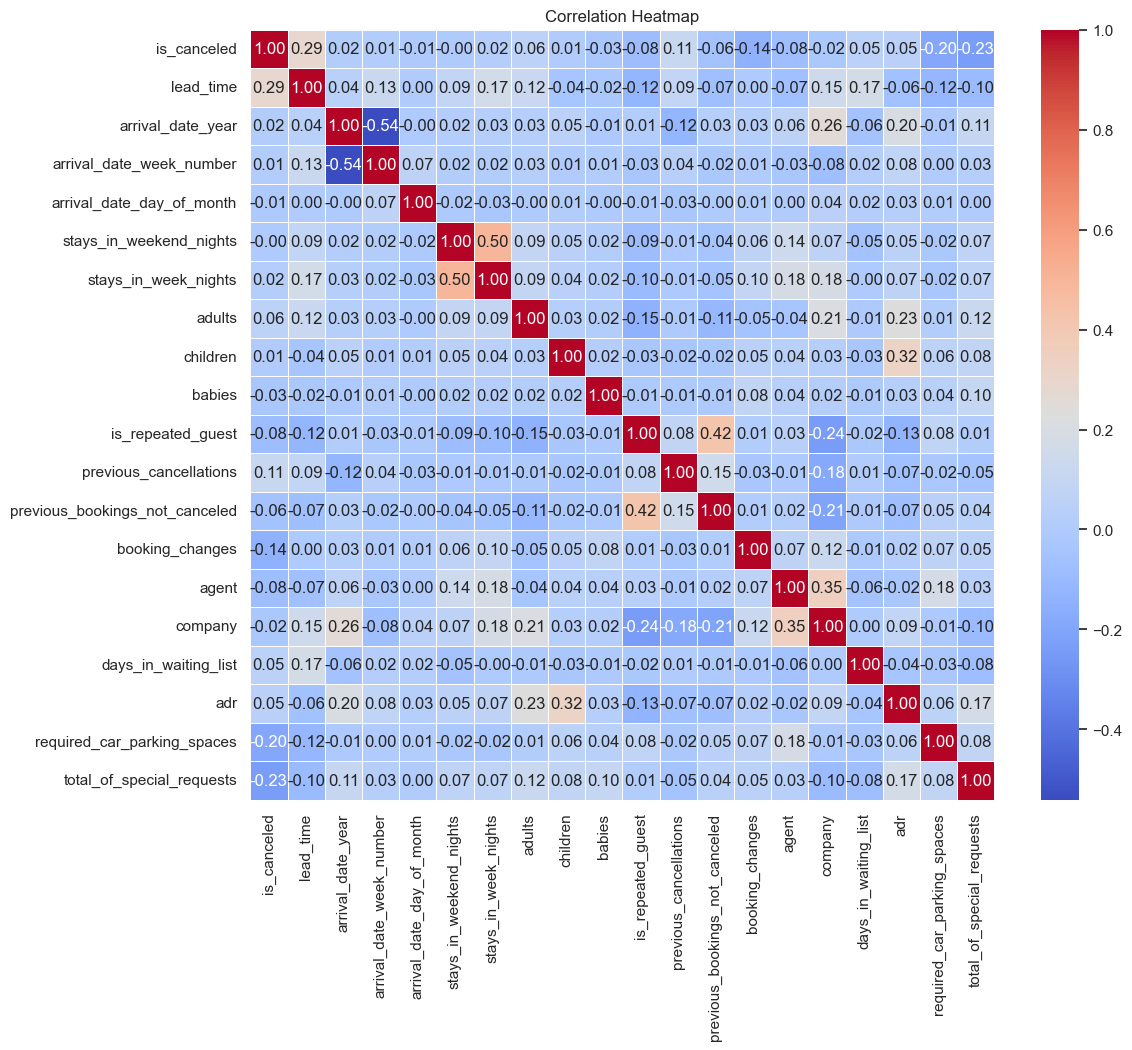

In [137]:

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


## Feature Engineering  & Selection

In [138]:

df = pd.read_csv("hotel_bookings.csv", parse_dates=["reservation_status_date"])

df['adr'] = pd.to_numeric(df['adr'], errors='coerce')
df = df.dropna(subset=['adr'])
df = df[~((df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0))]

df['country'] = df['country'].fillna(df['country'].mode()[0])
df['children'] = df['children'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

print("Step 1 Complete: Data Cleaned.")

Step 1 Complete: Data Cleaned.


In this step, new informative features were engineered, and all categorical
variables were transformed into numerical representations to make the dataset
compatible with machine learning algorithms.

### Feature Engineering
- Created `total_stay` by combining weekday and weekend stays
- Created `total_people` by summing adults, children, and babies

These engineered features provide a more meaningful representation of
booking behavior.

### Feature Transformation
- Dropped non-essential columns such as reservation status and date
- Applied One-Hot Encoding to low-cardinality categorical variables
- Applied Label Encoding to remaining categorical features

After this step, the dataset became fully numerical and ready for
feature selection, dimensionality reduction, and clustering.


In [139]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_people'] = df['adults'] + df['children'] + df['babies']

df_encoded = df.drop(['reservation_status', 'reservation_status_date'], axis=1)

low_card_cols = ['hotel', 'meal', 'market_segment', 'deposit_type', 'customer_type', 'distribution_channel']
df_encoded = pd.get_dummies(df_encoded, columns=low_card_cols, drop_first=True)

le = LabelEncoder()
object_cols = df_encoded.select_dtypes(include=['object']).columns
for col in object_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Step 2 Complete: reservation_status dropped and all objects encoded.")

Step 2 Complete: reservation_status dropped and all objects encoded.


## Feature Selection Using Filter Method (Correlation)

In this step, a correlation-based filter method was applied to identify
the most influential features related to booking cancellation.

### Methodology
- The target variable `is_canceled` was separated from the feature set
- Pearson correlation was computed between each feature and the target
- Absolute correlation values were used to measure strength of influence
- The top 10 most correlated features were selected

### Rationale
Filter methods are computationally efficient and provide a quick
statistical insight into feature relevance without involving any
machine learning model.

This step helps reduce dimensionality, remove irrelevant features,
and improve model interpretability.


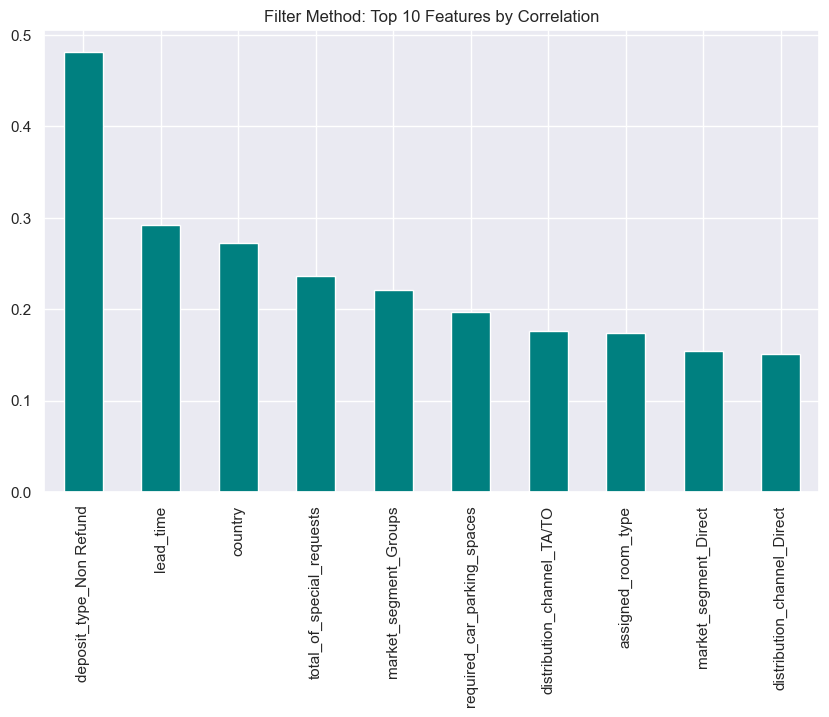

Filter Features (Top 10) Defined.


In [140]:
X = df_encoded.drop(['is_canceled'], axis=1)
y = df_encoded['is_canceled']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

plt.figure(figsize=(10, 6))
correlation_series = df_encoded.corr(numeric_only=True)['is_canceled'].abs().sort_values(ascending=False).drop('is_canceled')
correlation_series.head(10).plot(kind='bar', color='teal')
plt.title("Filter Method: Top 10 Features by Correlation")
plt.show()

filter_features = correlation_series.head(10).index.tolist()
print("Filter Features (Top 10) Defined.")

## Feature Selection Using Embedded and Wrapper Methods

In this step, two advanced feature selection techniques were applied
to identify the most relevant features influencing booking cancellation.

### 1. Lasso Regression (Embedded Method)
Lasso regression was used to perform feature selection by applying
L1 regularization. Features with non-zero coefficients were retained,
while less important features were automatically eliminated.

**Advantages:**
- Performs feature selection during model training
- Reduces overfitting
- Improves model interpretability

### 2. Recursive Feature Elimination (RFE)
RFE was applied using a Random Forest classifier as the estimator.
The algorithm recursively removed the least important features
until the top 10 most significant features were selected.

**Advantages:**
- Model-based feature evaluation
- High selection accuracy
- Considers feature interactions

### Visualization
Bar plots were used to visualize the selected features from both
Lasso and RFE methods, providing a clear comparison of feature importance.


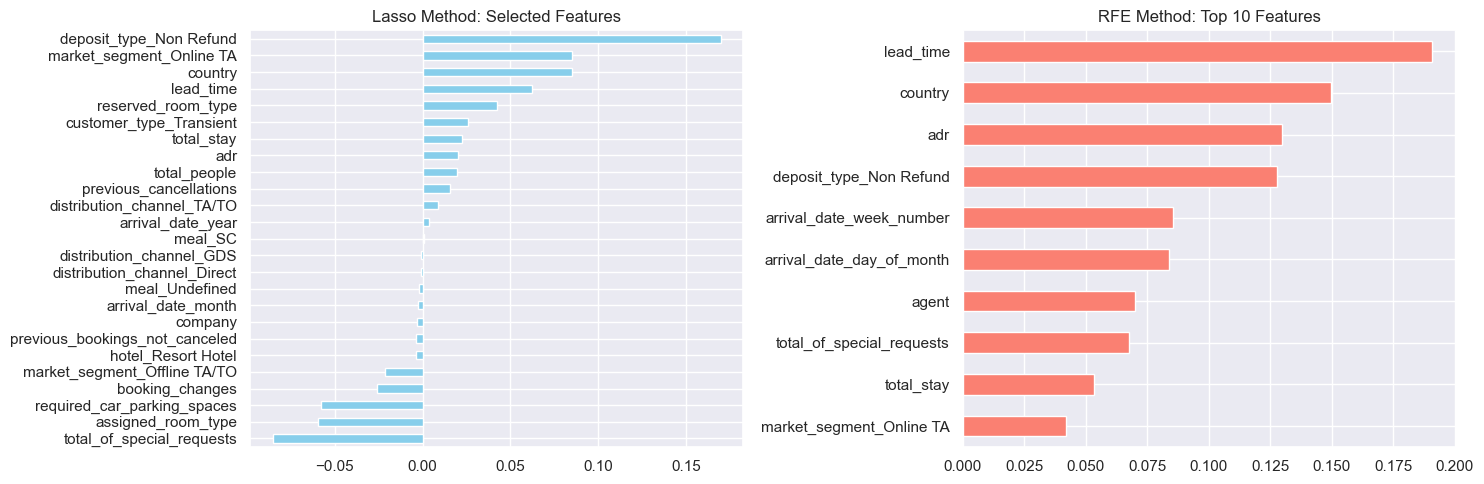

In [141]:
lasso = Lasso(alpha=0.005, random_state=42)
lasso.fit(X_scaled, y)
lasso_features = X.columns[lasso.coef_ != 0].tolist()

rfe = RFE(estimator=RandomForestClassifier(n_estimators=10, random_state=42), n_features_to_select=10)
rfe.fit(X_scaled, y)
rfe_features = X.columns[rfe.support_].tolist()

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
pd.Series(lasso.coef_, index=X.columns)[lasso.coef_ != 0].sort_values().plot(kind='barh', color='skyblue')
plt.title("Lasso Method: Selected Features")

plt.subplot(1, 2, 2)
pd.Series(rfe.estimator_.feature_importances_, index=rfe_features).sort_values().plot(kind='barh', color='salmon')
plt.title("RFE Method: Top 10 Features")
plt.tight_layout()
plt.show()

## Feature Selection Consensus (Voting Mechanism)

To ensure robust and reliable feature selection, the results of three
different feature selection techniques were combined:

- Filter Method (Correlation-based)
- Lasso Regression (Embedded Method)
- Recursive Feature Elimination (Wrapper Method)

A comparison table was created to track which features were selected
by each method. Each feature received one vote per method.

### Voting Strategy
Features selected by **two or more methods** were considered
**golden features**, as they demonstrated consistent importance
across multiple selection techniques.

This ensemble-based approach improves feature stability and
reduces selection bias.

### Outcome
The final set of selected features represents the most influential
variables affecting booking cancellation behavior and was used
in subsequent modeling and dimensionality reduction steps.


In [142]:
all_features = list(set(filter_features + lasso_features + rfe_features))

comparison_df = pd.DataFrame({'Feature': all_features})
comparison_df['Filter (Top 10)'] = comparison_df['Feature'].isin(filter_features)
comparison_df['Lasso (Selected)'] = comparison_df['Feature'].isin(lasso_features)
comparison_df['RFE (Top 10)'] = comparison_df['Feature'].isin(rfe_features)

comparison_df['Total_Votes'] = comparison_df[['Filter (Top 10)', 'Lasso (Selected)', 'RFE (Top 10)']].sum(axis=1)

print("Feature Selection Comparison Table (Target: Top 10):")
display(comparison_df.sort_values(by='Total_Votes', ascending=False))

golden_features = comparison_df[comparison_df['Total_Votes'] >= 2]['Feature'].tolist()
print(f"\nGolden Features (Selected by 2+ methods): {len(golden_features)} features found")
print(golden_features)

Feature Selection Comparison Table (Target: Top 10):


,Feature,Filter (Top 10),Lasso (Selected),RFE (Top 10),Total_Votes
19,total_of_special_requests,True,True,True,3
18,deposit_type_Non Refund,True,True,True,3
3,lead_time,True,True,True,3
21,country,True,True,True,3
16,distribution_channel_TA/TO,True,True,False,2
14,adr,False,True,True,2
13,required_car_parking_spaces,True,True,False,2
22,market_segment_Online TA,False,True,True,2
24,total_stay,False,True,True,2
6,distribution_channel_Direct,True,True,False,2



Golden Features (Selected by 2+ methods): 11 features found
['lead_time', 'assigned_room_type', 'distribution_channel_Direct', 'required_car_parking_spaces', 'adr', 'distribution_channel_TA/TO', 'deposit_type_Non Refund', 'total_of_special_requests', 'country', 'market_segment_Online TA', 'total_stay']


## Probability & Hypothesis Testing


 Probability Analysis of Booking Cancellation

This section analyzes booking cancellation behavior using probability
and conditional probability concepts.

 Overall Cancellation Probability

The overall probability of a booking being canceled was calculated as:

* **P(Cancel)** ≈ 37%
* **P(Not Cancel)** ≈ 63%

This indicates that the majority of bookings are completed successfully,
while a significant portion is still canceled.

 Conditional Probability by Hotel Type

The probability of cancellation varies by hotel type:

* **City Hotel** shows a higher cancellation rate than **Resort Hotel**
* This suggests different customer behavior and booking patterns
  across hotel categories

 Conditional Probability by Deposit Type

Cancellation probability was also analyzed based on deposit type:

* **Non-Refundable deposits** have an extremely high cancellation rate
* **Refundable** and **No Deposit** bookings show significantly lower
  cancellation probabilities

 Key Insight

Deposit type is one of the strongest indicators of cancellation behavior,
which aligns with the results obtained from feature selection methods.


In [143]:


p_cancel = (df["is_canceled"] == 1).mean()
p_not_cancel = 1 - p_cancel

print("P(Cancel) =", p_cancel)
print("P(Not Cancel) =", p_not_cancel)

p_cancel_given_hotel = df.groupby("hotel")["is_canceled"].mean()
print("\nP(Cancel | hotel):")
print(p_cancel_given_hotel)

p_cancel_given_deposit = df.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False)
print("\nP(Cancel | deposit_type):")
print(p_cancel_given_deposit)



P(Cancel) = 0.37235306509374344
P(Not Cancel) = 0.6276469349062566

P(Cancel | hotel):
hotel
City Hotel      0.418727
Resort Hotel    0.280018
Name: is_canceled, dtype: float64

P(Cancel | deposit_type):
deposit_type
Non Refund    0.993624
No Deposit    0.285386
Refundable    0.222222
Name: is_canceled, dtype: float64


In this section, a probabilistic analysis is performed on the
**Average Daily Rate (ADR)** to understand its statistical behavior.

The ADR values were first cleaned by removing missing observations.
A **Normal distribution** was then fitted to the ADR data using
maximum likelihood estimation, resulting in the following parameters:

- Mean (μ): represents the average ADR
- Standard deviation (σ): measures price variability

Using the fitted distribution, the probability of observing a booking
with **ADR greater than 150** was calculated.

The result indicates that approximately **17% of bookings have an ADR
higher than 150**, suggesting that high-priced bookings constitute a
significant but minority portion of the dataset.

This analysis provides insight into pricing behavior and supports
further feature selection and clustering steps.


In [144]:

adr = df["adr"].dropna()

mu, sigma = norm.fit(adr)   # fit Normal distribution
prob_adr_gt_150 = 1 - norm.cdf(150, loc=mu, scale=sigma)

print("Fitted Normal for ADR:")
print("mu =", mu)
print("sigma =", sigma)
print("P(ADR > 150) =", prob_adr_gt_150)


Fitted Normal for ADR:
mu = 102.44463956182852
sigma = 50.063755620997235
P(ADR > 150) = 0.17108255366956282


## Bivariate Statistical Analysis: ADR and Cancellation Status

To examine whether pricing behavior differs between canceled and
non-canceled bookings, an **independent two-sample t-test (Welch’s t-test)**
was conducted on the **Average Daily Rate (ADR)**.

The dataset was divided into two independent groups:
- ADR values for canceled bookings
- ADR values for non-canceled bookings

The null hypothesis (H₀) assumes that there is no difference in the mean
ADR between the two groups, while the alternative hypothesis (H₁)
suggests a statistically significant difference.

The test results yielded a very small p-value (p < 0.05), leading to the
rejection of the null hypothesis. This indicates that the mean ADR for
canceled bookings is **significantly different** from that of
non-canceled bookings.

This finding suggests that pricing plays an important role in booking
cancellation behavior and motivates further feature selection and
modeling steps.


In [145]:

adr_cancel = df[df["is_canceled"] == 1]["adr"].dropna()
adr_not_cancel = df[df["is_canceled"] == 0]["adr"].dropna()

t_stat, p_value = ttest_ind(adr_cancel, adr_not_cancel, equal_var=False)

print("T-statistic =", t_stat)
print("P-value =", p_value)

alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H0 (ADR means are significantly different).")
else:
    print("Decision: Fail to reject H0 (No significant difference in ADR means).")


T-statistic = 13.528677215550283
P-value = 1.1672088891847922e-41
Decision: Reject H0 (ADR means are significantly different).


## Association Between Hotel Type and Cancellation Status

To examine whether hotel type is statistically associated with booking
cancellation behavior, a **Chi-Square Test of Independence** was applied.

A contingency table was constructed between:
- Hotel type (City Hotel, Resort Hotel)
- Cancellation status (Canceled vs Not Canceled)

The null hypothesis (H₀) assumes that hotel type and cancellation status
are independent, while the alternative hypothesis (H₁) assumes a
statistical association between them.

The test produced a highly significant p-value (p < 0.05), leading to
the rejection of the null hypothesis. This confirms that **hotel type is
significantly associated with cancellation behavior**, indicating that
different hotel categories experience different cancellation patterns.


In [146]:
cont_table = pd.crosstab(df["hotel"], df["is_canceled"])
chi2, p_value, dof, expected = chi2_contingency(cont_table)

print("Chi-square =", chi2)
print("P-value =", p_value)
print("Degrees of freedom =", dof)

alpha = 0.05
if p_value < alpha:
    print("Decision: Reject H0 (Hotel type is associated with cancellation).")
else:
    print("Decision: Fail to reject H0 (No association detected).")


Chi-square = 2173.744840742247
P-value = 0.0
Degrees of freedom = 1
Decision: Reject H0 (Hotel type is associated with cancellation).


## Dimensionality Reduction (PCA)

### Goal
Reduce the dimensionality of hotel booking features to visualize booking behavior patterns.

### Feature Selection & Preprocessing

In [147]:

df['children'].fillna(0, inplace=True)
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

features = ['lead_time', 'total_stay', 'adults', 'children']
X = df[features]


### Standardization

In [148]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Apply PCA

In [149]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Captured:", pca.explained_variance_ratio_.sum())


Explained Variance Ratio: [0.31286291 0.25572747]
Total Variance Captured: 0.568590383375176


### PCA Visualization

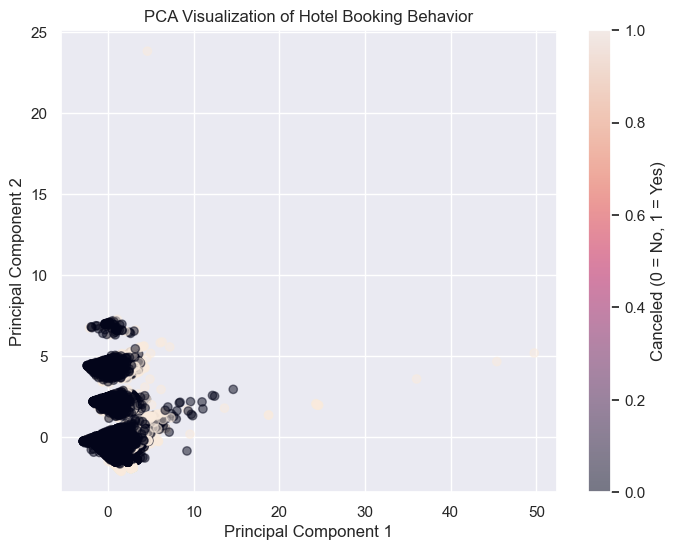

In [150]:

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['is_canceled'], alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Hotel Booking Behavior")
plt.colorbar(label="Canceled (0 = No, 1 = Yes)")
plt.show()


### Interpretation
PCA reduced the original feature space into two principal components while retaining most of the variance.
The visualization reveals clear behavioral patterns between canceled and non-canceled bookings.